In [4]:
# ADDS THE PARENT DIRECTORY TO SYS.PATH
import sys
import os

# Add the project root directory (one level up) to sys.path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

In [5]:
from src.integrator.integrate import phi, phi_inv
import numpy as np
import matplotlib.pyplot as plt
import rebound

In [6]:
arr = np.load("../boundary_test1/e0_5__v2_eps0_001__deltmax_100.npy")
N = arr.shape[1]
bound_vt = np.zeros((N,2))
bound_vt[:,0] = arr[1]
bound_vt[:,1] = arr[0]

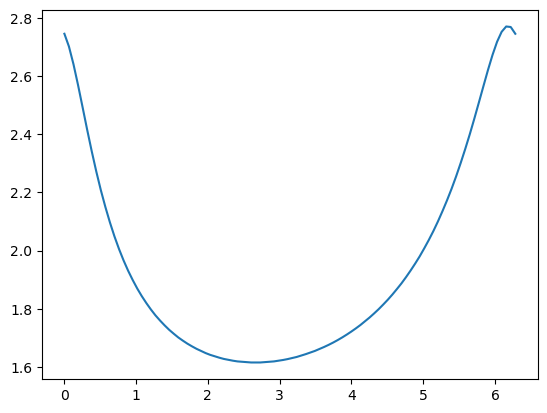

In [7]:
plt.plot(bound_vt[:,1], bound_vt[:,0])
plt.show()

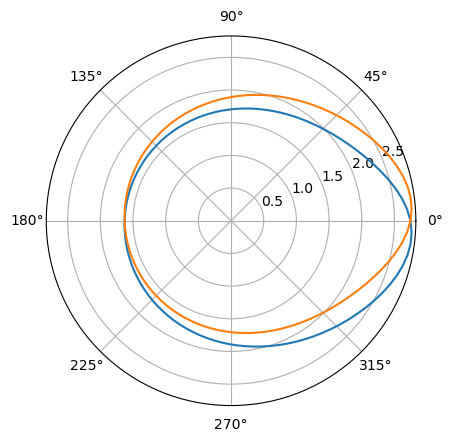

In [8]:
plt.polar(bound_vt[:,1], bound_vt[:,0])
plt.polar(-bound_vt[:,1], bound_vt[:,0])
plt.show()

In [9]:
print(np.floor(14.5))

14.0


In [10]:
NE_1_begin_vt = []

mid = 15

v, t = phi_inv(e = 0.5, v = bound_vt[mid,0], t = bound_vt[mid,1])
NE_1_begin_vt.append(np.array([v,t]))

max_d = 0.2
step = 1 # fractional jump over the indices
current = mid - 1

while current > 2:
    i = int(np.floor(current))
    f = current - i
    print("i = ", i, "f = ", f)
    v0 = bound_vt[i,0]*(1-f) + bound_vt[i+1,0]*f
    t0 = bound_vt[i,1]*(1-f) + bound_vt[i+1,1]*f

    v1, t1 = phi_inv(e = 0.5, v = v0, t = t0)
    prev_v1 = NE_1_begin_vt[-1][0]
    prev_t1 = NE_1_begin_vt[-1][1]
    while (v1 - prev_v1)**2 + (t1 - prev_t1)**2 > max_d**2:
        current = current + step/2
        step = step/2
        i = int(np.floor(current))
        f = current - i
        print(current, " i = ", i, "f = ", f) 
        v0 = bound_vt[i,0]*(1-f) + bound_vt[i+1,0]*f
        t0 = bound_vt[i,1]*(1-f) + bound_vt[i+1,1]*f
    
        v1, t1 = phi_inv(e = 0.5, v = v0, t = t0)
    
    NE_1_begin_vt.append(np.array([v1,t1]))
    current = current - step
    
print(len(NE_1_begin_vt))
print(NE_1_begin_vt)

i =  14 f =  0


14.5  i =  14 f =  0.5
i =  14 f =  0.0
i =  13 f =  0.5
i =  13 f =  0.0
i =  12 f =  0.5
i =  12 f =  0.0
i =  11 f =  0.5
i =  11 f =  0.0
i =  10 f =  0.5
i =  10 f =  0.0
i =  9 f =  0.5
i =  9 f =  0.0
i =  8 f =  0.5
i =  8 f =  0.0
i =  7 f =  0.5
i =  7 f =  0.0
i =  6 f =  0.5
i =  6 f =  0.0
i =  5 f =  0.5
5.75  i =  5 f =  0.75
i =  5 f =  0.5
i =  5 f =  0.25
i =  5 f =  0.0
i =  4 f =  0.75
i =  4 f =  0.5
i =  4 f =  0.25
4.375  i =  4 f =  0.375
i =  4 f =  0.25
i =  4 f =  0.125
i =  4 f =  0.0
i =  3 f =  0.875
i =  3 f =  0.75
i =  3 f =  0.625
i =  3 f =  0.5
i =  3 f =  0.375
3.4375  i =  3 f =  0.4375
i =  3 f =  0.375
i =  3 f =  0.3125
i =  3 f =  0.25
i =  3 f =  0.1875
i =  3 f =  0.125
i =  3 f =  0.0625
i =  3 f =  0.0
i =  2 f =  0.9375
i =  2 f =  0.875
i =  2 f =  0.8125
i =  2 f =  0.75
i =  2 f =  0.6875
2.71875  i =  2 f =  0.71875
i =  2 f =  0.6875
i =  2 f =  0.65625
i =  2 f =  0.625
i =  2 f =  0.59375
i =  2 f =  0.5625
i =  2 f =  0.53125
i =  

In [11]:
NE_1_end_vt = []

mid = 15

v, t = phi_inv(e = 0.5, v = bound_vt[mid,0], t = bound_vt[mid,1])
NE_1_end_vt.append(np.array([v,t]))

max_d = 0.2
step = 1 # fractional jump over the indices
current = mid + 1

while current < 30:
    i = int(np.floor(current))
    f = current - i
    v0 = bound_vt[i,0]*(1-f) + bound_vt[i+1,0]*f
    t0 = bound_vt[i,1]*(1-f) + bound_vt[i+1,1]*f

    v1, t1 = phi_inv(e = 0.5, v = v0, t = t0)
    prev_v1 = NE_1_end_vt[-1][0]
    prev_t1 = NE_1_end_vt[-1][1]
    while (v1 - prev_v1)**2 + (t1 - prev_t1)**2 > max_d**2:
        current = current - step/2
        step = step/2
        i = int(np.floor(current))
        f = current - i
        v0 = bound_vt[i,0]*(1-f) + bound_vt[i+1,0]*f
        t0 = bound_vt[i,1]*(1-f) + bound_vt[i+1,1]*f
    
        v1, t1 = phi_inv(e = 0.5, v = v0, t = t0)
    
    NE_1_end_vt.append(np.array([v1,t1]))
    current = current + step
    

print(len(NE_1_end_vt))
print(NE_1_end_vt)



57
[array([ 1.22258113, -3.87311028]), array([ 1.23574518, -3.98800791]), array([ 1.24952541, -4.09261117]), array([ 1.26863668, -4.22331939]), array([ 1.28911973, -4.3442738 ]), array([ 1.31664618, -4.48660333]), array([ 1.34666809, -4.61942356]), array([ 1.38567163, -4.76758297]), array([ 1.42876064, -4.90611223]), array([ 1.48622861, -5.06161998]), array([ 1.55141586, -5.20756199]), array([ 1.64760986, -5.38206479]), array([ 1.70300611, -5.46611425]), array([ 1.76380135, -5.54793528]), array([ 1.83938955, -5.63768042]), array([ 1.92359546, -5.72545688]), array([ 2.016664  , -5.81129105]), array([ 2.11802349, -5.89525968]), array([ 2.24045855, -5.98856443]), array([ 2.36536792, -6.08098816]), array([ 2.48024947, -6.17300712]), array([ 2.56764743, -6.26515881]), array([ 2.61447987, -6.37757526]), array([ 2.59062235, -6.49308   ]), array([ 2.51312533, -6.61159289]), array([ 2.40905236, -6.73253016]), array([ 2.29194526, -6.86334577]), array([ 2.18083119, -6.99575939]), array([ 2.080749

In [12]:
NE_1_vt = NE_1_begin_vt[:0:-1] + NE_1_end_vt
NE_1_vt = np.array(NE_1_vt)
print(NE_1_vt.shape)
print(NE_1_vt)

(124, 2)
[[  1.40897847  -9.64014857]
 [  1.41595902  -9.45462565]
 [  1.42680498  -9.27540435]
 [  1.44118883  -9.10235871]
 [  1.45888028  -8.93534772]
 [  1.47972528  -8.77421986]
 [  1.50363133  -8.61881672]
 [  1.53055716  -8.46897612]
 [  1.56050522  -8.3245345 ]
 [  1.59351608  -8.1853291 ]
 [  1.62966382  -8.05119957]
 [  1.66905173  -7.92198954]
 [  1.71180737  -7.79754777]
 [  1.75807601  -7.67772929]
 [  1.80801088  -7.56239641]
 [  1.86175805  -7.45141955]
 [  1.91943284  -7.34467815]
 [  1.98108313  -7.24206139]
 [  2.04663339  -7.14346887]
 [  2.11580141  -7.04881105]
 [  2.18797924  -6.95800921]
 [  2.26207311  -6.8709947 ]
 [  2.33630943  -6.78770674]
 [  2.40804371  -6.70808811]
 [  2.52871492  -6.55960058]
 [  2.58892323  -6.42479194]
 [  2.56578192  -6.30231755]
 [  2.47180985  -6.19020077]
 [  2.32832651  -6.07573113]
 [  2.18083477  -5.96852869]
 [  2.04766947  -5.867044  ]
 [  1.93336728  -5.77029205]
 [  1.83684291  -5.67764416]
 [  1.75544967  -5.58868003]
 [  1

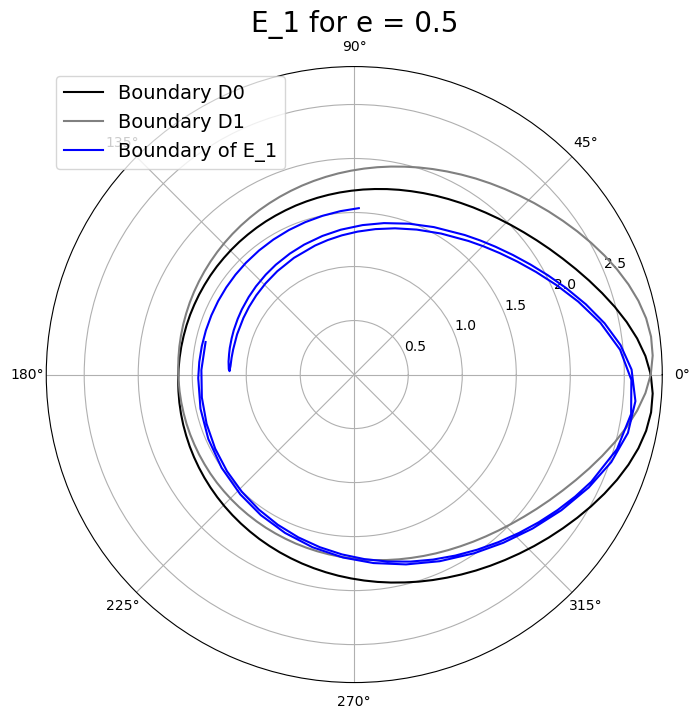

In [21]:
arr = NE_1_vt

plt.figure(figsize=(8,8))
plt.polar(bound_vt[:,1], bound_vt[:,0], label='Boundary D0', color='black')
plt.polar(-bound_vt[:,1], bound_vt[:,0], label='Boundary D1', color='grey')
plt.polar(arr[:,1], arr[:,0], label='Boundary of E_1', color='blue')
plt.title('E_1 for e = 0.5', fontsize=20)
plt.legend(fontsize=14)
plt.savefig('../figures/E_1_e0.5.png', dpi=300)
plt.show()